In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

print("CPU cores (os.cpu_count):", os.cpu_count())


CPU cores (os.cpu_count): 8


In [3]:
!pip install -q findspark
!pip install -q xgboost


In [4]:
import findspark
findspark.init()
from pyspark.sql import SparkSession
from pyspark import SparkContext, SparkConf

spark = (
    SparkSession.builder
    .appName("XGBoost_PCA_K25")
    .master("local[*]")
    .config("spark.ui.port", "4050")
    .config("spark.driver.memory", "35g")
    .config("spark.driver.memoryOverhead", "4g")
    .config("spark.sql.shuffle.partitions", "16")
    .config("spark.default.parallelism", "16")
    .config("spark.serializer", "org.apache.spark.serializer.KryoSerializer")
    .config(
        "spark.jars.packages",
        "ml.dmlc:xgboost4j-spark_2.12:1.7.6"
    )
    .getOrCreate()
)


spark


In [ ]:
# spark.stop()

In [5]:
!pip install -q ngrok


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 36.9 MB/s eta 0:00:00


In [6]:
!wget -q https://bin.equinox.io/c/bNyj1mQVY4c/ngrok-v3-stable-linux-amd64.tgz
!tar -xzf ngrok-v3-stable-linux-amd64.tgz
!chmod +x ngrok
get_ipython().system_raw('!./ngrok http 4050 &')


In [6]:
!./ngrok authtoken 372K2OENTZEIyObJBECpiQP0wUR_BgEkQykJerjtRoPQJsoH

/bin/bash: line 1: ./ngrok: No such file or directory


In [7]:
!nohup ./ngrok http 4050 --log=stdout --log-format=logfmt > ngrok.log 2>&1 &


In [29]:
parquet_path_raw = "/content/drive/MyDrive/bigdata/cic_ddos_raw.parquet"
parquet_path_25 = r"/content/drive/MyDrive/bigdata/cic_ddos_pca_25.parquet"
parquet_path_21 = r"/content/drive/MyDrive/bigdata/cic_ddos_pca_21.parquet"
parquet_path_27 = r"/content/drive/MyDrive/bigdata/cic_ddos_rf_27.parquet"

df_feature_raw = spark.read.parquet(parquet_path_raw).cache()
df_feature_25 = spark.read.parquet(parquet_path_25).cache()
df_feature_21 = spark.read.parquet(parquet_path_21).cache()
df_feature_27 = spark.read.parquet(parquet_path_27).cache()

df_feature_25.printSchema(), df_feature_21.printSchema(), df_feature_27.printSchema(), df_feature_raw.printSchema()

root
 |-- pca_k25: vector (nullable = true)
 |-- label: string (nullable = true)

root
 |-- pca_k21: vector (nullable = true)
 |-- label: string (nullable = true)

root
 |-- label: string (nullable = true)
 |-- rf_27: vector (nullable = true)

root
 |-- features: vector (nullable = true)
 |-- label: string (nullable = true)



(None, None, None, None)

In [30]:
from pyspark.ml.feature import StringIndexer
label_indexer = StringIndexer(
    inputCol="label",
    outputCol="label_index",
    handleInvalid="skip"
)
df_indexed_25 = label_indexer.fit(df_feature_25).transform(df_feature_25)
df_indexed_21 = label_indexer.fit(df_feature_21).transform(df_feature_21)
df_indexed_27 = label_indexer.fit(df_feature_27).transform(df_feature_27)
df_indexed_raw = label_indexer.fit(df_feature_raw).transform(df_feature_raw)


In [31]:
from pyspark.sql.functions import lit

def split_train_test(df_indexed):
  fractions = (
      df_indexed
      .select("label")
      .distinct()
      .withColumn("fraction", lit(0.02))
      .rdd.collectAsMap()
  )

  test_df = df_indexed.sampleBy(
      "label",
      fractions,
      seed=42
  )
  return test_df, df_indexed.subtract(test_df)

test_df_25, train_df_25 = split_train_test(df_indexed_25)
test_df_21, train_df_21 = split_train_test(df_indexed_21)
test_df_27, train_df_27 = split_train_test(df_indexed_27)
test_df_raw, train_df_raw = split_train_test(df_indexed_raw)

In [35]:
from pyspark.sql import functions as F

def weight_df(df):
  label_counts = df.groupBy("label").count()

  stats = label_counts.agg(
      F.sum("count").alias("total_train"),
      F.count("label").alias("num_labels")
  ).first()

  total_train = float(stats["total_train"])
  num_labels = float(stats["num_labels"])

  weights = (
      label_counts
      .withColumn(
          "weight",
          F.lit(float(total_train)) / (F.col("count") * F.lit(float(num_labels)))
      )
      .select("label", "weight")
  )

  df_w  = df.join(weights, on="label", how="left")
  return df_w

# train_w_raw = weight_df(train_df_raw)
test_w_raw = weight_df(test_df_raw)

# train_w_25 = weight_df(train_df_25)
test_w_25 = weight_df(test_df_25)

# train_w_21 = weight_df(train_df_21)
test_w_21 = weight_df(test_df_21)

# train_w_27 = weight_df(train_df_27)
test_w_27 = weight_df(test_df_27)
# train_w.select("label", "weight").distinct().show()



In [ ]:
# print("Train distribution")
# train_df.groupBy("label_index").count().orderBy("label_index").show()
# print("Test distribution")
# test_df.groupBy("label_index").count().orderBy("label_index").show()


In [40]:
from xgboost.spark import SparkXGBClassifier

def xgb_init(feature_name):
  xgb = SparkXGBClassifier(
      features_col=feature_name,
      label_col="label_index",
      weight_col="weight",

      eval_metric="auc",

      num_workers=8,

      max_depth=8,
      eta=0.1,
      subsample=0.8,
      colsample_bytree=0.8,

      n_estimators=300,
      tree_method="hist",

      seed=42
  )
  return xgb

xgb = xgb_init(feature_name='features')
xgb_model_raw = xgb.fit(test_w_raw)

xgb = xgb_init(feature_name='pca_k25')
xgb_model_25 = xgb.fit(test_w_25)

xgb = xgb_init(feature_name='pca_k21')
xgb_model_21 = xgb.fit(test_w_21)

xgb = xgb_init(feature_name='rf_27')
xgb_model_27 = xgb.fit(test_w_27)





INFO:XGBoost-PySpark:Running xgboost-3.1.2 on 8 workers with
	booster params: {'objective': 'multi:softprob', 'colsample_bytree': 0.8, 'device': 'cpu', 'eval_metric': 'auc', 'max_depth': 8, 'subsample': 0.8, 'tree_method': 'hist', 'eta': 0.1, 'seed': 42, 'num_class': 10, 'nthread': 1}
	train_call_kwargs_params: {'verbose_eval': True, 'num_boost_round': 300}
	dmatrix_kwargs: {'nthread': 1, 'missing': nan}
INFO:XGBoost-PySpark:Finished xgboost training!
INFO:XGBoost-PySpark:Running xgboost-3.1.2 on 8 workers with
	booster params: {'objective': 'multi:softprob', 'colsample_bytree': 0.8, 'device': 'cpu', 'eval_metric': 'auc', 'max_depth': 8, 'subsample': 0.8, 'tree_method': 'hist', 'eta': 0.1, 'seed': 42, 'num_class': 10, 'nthread': 1}
	train_call_kwargs_params: {'verbose_eval': True, 'num_boost_round': 300}
	dmatrix_kwargs: {'nthread': 1, 'missing': nan}
INFO:XGBoost-PySpark:Finished xgboost training!
INFO:XGBoost-PySpark:Running xgboost-3.1.2 on 8 workers with
	booster params: {'objectiv

In [41]:
xgb_model_raw_path = r"/content/drive/MyDrive/bigdata/model/xgboost_cic_ddos_2019_raw"
xgb_model_raw.write().overwrite().save(xgb_model_raw_path)

xgb_model_25_path = r"/content/drive/MyDrive/bigdata/model/xgboost_cic_ddos_2019_pca_k25"
xgb_model_25.write().overwrite().save(xgb_model_25_path)

xgb_model_21_path = r"/content/drive/MyDrive/bigdata/model/xgboost_cic_ddos_2019_pca_k21"
xgb_model_21.write().overwrite().save(xgb_model_21_path)

xgb_model_27_path = r"/content/drive/MyDrive/bigdata/model/xgboost_cic_ddos_2019_rf_k27"
xgb_model_27.write().overwrite().save(xgb_model_27_path)



In [ ]:
pred_xgb = rf_model.transform(test_w)

In [ ]:
from pyspark.sql import functions as F

def confusion_matrix_spark(df, label_col="label_index", pred_col="prediction"):
    return (
        df
        .groupBy(label_col, pred_col)
        .count()
        .orderBy(label_col, pred_col)
    )
print("Confusion Matrix K25")
cm_k21 = confusion_matrix_spark(pred_xgb)
cm_k21.show()

Confusion Matrix K21
+-----------+----------+-----+
|label_index|prediction|count|
+-----------+----------+-----+
|        0.0|       0.0|85997|
|        0.0|       1.0| 4032|
|        0.0|       2.0|   18|
|        0.0|       3.0| 4415|
|        0.0|       4.0| 8423|
|        0.0|       6.0|    4|
|        0.0|       7.0|    9|
|        1.0|       0.0|12511|
|        1.0|       1.0|55373|
|        1.0|       2.0|   30|
|        1.0|       3.0|  200|
|        1.0|       4.0|32836|
|        1.0|       6.0|  160|
|        1.0|       7.0|    5|
|        2.0|       0.0|  141|
|        2.0|       1.0|   85|
|        2.0|       2.0|89881|
|        2.0|       4.0|  266|
|        2.0|       6.0|    1|
|        2.0|       7.0|   77|
+-----------+----------+-----+
only showing top 20 rows


In [ ]:
from pyspark.ml.feature import StringIndexer



label_indexer_25 = StringIndexer(
    inputCol="label",
    outputCol="label_index",
    handleInvalid="skip"
)

label_model_25 = label_indexer_25.fit(df_feature)
def build_label_map(label_model):
    return spark.createDataFrame(
        [(i, l) for i, l in enumerate(label_model.labels)],
        ["label_index", "label_name"]
    )

label_map_25 = build_label_map(label_model_25)
from pyspark.sql import functions as F

def confusion_matrix_2d(df, label_col="label_index", pred_col="prediction"):
    return (
        df
        .groupBy(label_col, pred_col)
        .count()
        .groupBy(label_col)
        .pivot(pred_col)
        .sum("count")
        .na.fill(0)
        .orderBy(label_col)
    )
def attach_label_name(cm_df, label_map):
    return (
        cm_df
        .join(label_map, on="label_index", how="left")
        .orderBy("label_index")
    )
cm_k25 = attach_label_name(
    confusion_matrix_2d(pred_xgb),
    label_map_25
)

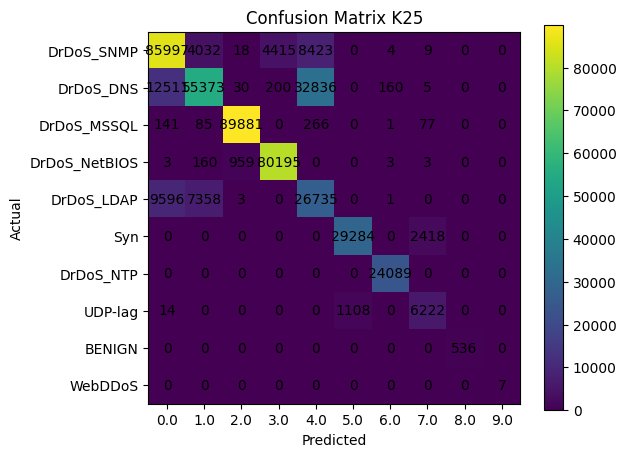

In [ ]:
import matplotlib.pyplot as plt

def plot_confusion_matrix(cm_spark, title):
    pdf = cm_spark.toPandas()

    y_labels = pdf["label_name"]
    pdf = pdf.drop(columns=["label_index", "label_name"])
    mat = pdf.values

    plt.figure(figsize=(6, 5))
    plt.imshow(mat)
    plt.colorbar()
    plt.xticks(range(mat.shape[1]), pdf.columns)
    plt.yticks(range(mat.shape[0]), y_labels)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(title)

    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            plt.text(j, i, int(mat[i, j]), ha="center", va="center")

    plt.show()
plot_confusion_matrix(cm_k25, "Confusion Matrix K25")

In [ ]:
from sklearn.metrics import classification_report

def evaluate(pdf):
  print(
      classification_report(
          pdf["label_index"],
          pdf["prediction"],
          digits=4
      )
  )

pdf_25 = pred_xgb.select("label_index", "prediction").toPandas()

print('K_25')
evaluate(pdf_25)

K_25
              precision    recall  f1-score   support

         0.0     0.7943    0.8357    0.8145    102898
         1.0     0.8264    0.5476    0.6587    101115
         2.0     0.9889    0.9937    0.9913     90451
         3.0     0.9456    0.9861    0.9654     81323
         4.0     0.3917    0.6119    0.4776     43693
         5.0     0.9635    0.9237    0.9432     31702
         6.0     0.9930    1.0000    0.9965     24089
         7.0     0.7124    0.8472    0.7740      7344
         8.0     1.0000    1.0000    1.0000       536
         9.0     1.0000    1.0000    1.0000         7

    accuracy                         0.8244    483158
   macro avg     0.8616    0.8746    0.8621    483158
weighted avg     0.8465    0.8244    0.8270    483158



In [ ]:
spark.stop()